# Day 67 - Random Forest 

## Intuition

- Random Forest is one of the most powerful machine learning algorithms
- It works well for both:
  - Classification  
  - Regression  

- It often gives strong performance even without extensive hyperparameter tuning

---

## Key Insight

- The scientist behind Random Forest, Leo Breiman, stated that:
  > Even with default hyperparameters, Random Forest performs very well.

- This makes it a robust and beginner-friendly algorithm

---

## Prerequisites

- Understanding Decision Trees is essential
- Because:
  Random Forest is a collection of multiple Decision Trees

---

## Core Idea

### Forest = Group of Trees
- A "forest" simply refers to multiple decision trees combined together

---

## Why "Random"?

Randomness comes from the Bagging technique

### Bagging = Bootstrapping + Aggregation

#### 1. Bootstrapping (Sampling)
- Random selection of data with replacement
- Each tree is trained on a different subset of data

#### 2. Aggregation
- Combine outputs of all trees:
  - Classification → Majority Voting  
  - Regression → Averaging  

- This randomness reduces overfitting and improves model performance

---

## Important Concept

- If Decision Trees are used as base models inside a Bagging framework:
  
  Then it is called Random Forest

---

## 

Random Forest = Bagging (Bootstrap + Aggregation) + Decision Trees

---

## 

> Random Forest is an ensemble of decision trees built using bagging, where randomness in data sampling helps create a strong and reliable model.

#  - Random Forest (Working & Sampling)

## Dataset and Base Models

- Consider a dataset with 1000 rows
- Random Forest uses multiple base models:
  - Decision Trees act as the base models

- Each decision tree is **not trained on the full dataset**
- Instead, **samples of the dataset** are given to each model

---

## Sampling Techniques

To create diversity among trees, different types of sampling are used:

### 1. Row Sampling
- Random subset of rows (data points) is selected

### 2. Column Sampling (Feature Sampling)
- Random subset of features is selected

### 3. Combination of Row and Column Sampling
- Both rows and features are randomly selected

---

## Data Distribution to Models

- Example:
  - From 1000 rows, 500 rows are given to each model
  - These rows are selected randomly

- Each model receives a **different subset of data**
- This ensures that all decision trees learn differently

---

## Sampling Methods

### 1. With Replacement
- A row is selected and then placed back into the dataset
- It can be selected again in future draws
- Duplicate rows can appear in the sample

### 2. Without Replacement
- A row is selected and removed from the dataset
- It cannot be selected again
- No duplicate rows in the sample

---

##  

- Since each decision tree gets different data:
  - All trees become **different from each other**
  - This diversity improves overall model performance

---

## Model Training

- Each sampled dataset is used to train a separate decision tree
- All decision trees are trained independently

---

## Aggregation

After training, predictions from all models are combined

### Classification Problem

- Input (query point) is given to all decision trees
- Each tree outputs a class label

- Example:
  - 43 trees predict class 0
  - 57 trees predict class 1

- Final Output:
  - Class 1 (Majority Voting)

---

### Regression Problem

- Input is given to all decision trees
- Each tree outputs a numerical value

- Final Output:
  - Mean (average) of all predictions

---

##

- Random Forest builds multiple decision trees using sampled data
- Each tree gives its own prediction
- Final result is obtained by combining all predictions:
  - Majority vote (classification)
  - Mean (regression)

## Basic code for undersatnding Random forest 

In [65]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [66]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [67]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.253889,0.440347,-0.980689,-2.468879,-2.295632,0
1,0.596395,-1.243372,2.391397,0.949146,-0.767854,1
2,1.503823,0.619253,-1.183074,-1.214497,-1.602159,1
3,1.255497,-0.208272,-0.937155,0.357578,-1.734181,0
4,-2.681968,-1.495277,-1.939150,-0.037630,-0.758795,0


In [68]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [69]:
# row sampling (Bootstrapping)

def sample_rows(df, percent):
    """
    This function performs row sampling on the dataset.

    Parameters:
    df (DataFrame): Input dataset
    percent (float): Percentage of data to sample (e.g., 0.5 for 50%)

    Returns:
    DataFrame: Sampled dataset (with replacement)
    """

    # Calculate number of rows to sample
    n_rows = int(percent * df.shape[0])

    # Perform sampling with replacement (bootstrapping)
    sampled_df = df.sample(n_rows, replace=True)

    return sampled_df

In [70]:
import random
#  feature sampling (Column Sampling)

def sample_features(df, percent):
    """
    This function performs feature (column) sampling.

    Parameters:
    df (DataFrame): Input dataset
    percent (float): Percentage of features to sample

    Returns:
    DataFrame: Dataset with selected features + target column
    """

    # Exclude target column from sampling
    feature_cols = df.columns.tolist()[:-1]

    # Number of features to sample
    n_cols = int(percent * len(feature_cols))

    # Randomly select feature columns
    sampled_cols = random.sample(feature_cols, n_cols)

    # Create new dataframe with sampled features
    new_df = df[sampled_cols].copy()

    # Add target column back
    new_df['target'] = df['target']

    return new_df

In [71]:
# Function for combined sampling (Row + Column Sampling)

def combined_sampling(df, row_percent, col_percent):
    """
    This function performs both row sampling and column (feature) sampling.

    Parameters:
    df (DataFrame): Input dataset
    row_percent (float): Percentage of rows to sample
    col_percent (float): Percentage of columns (features) to sample

    Returns:
    DataFrame: Sampled dataset with selected rows and columns
    """

    # Step 1: Row sampling (bootstrapping)
    new_df = sample_rows(df, row_percent)

    # Step 2: Column sampling (feature sampling)
    sampled_df = sample_features(new_df, col_percent)

    return sampled_df

In [93]:
df.shape

(100, 6)

In [113]:
df1 = combined_sampling(df,0.5,0.5)

In [114]:
df2 = combined_sampling(df,0.5,0.5)

In [115]:
df3 = combined_sampling(df,0.5,0.5)

In [116]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col3', 'target'], dtype='str')
Index(['col5', 'col3', 'target'], dtype='str')
Index(['col5', 'col4', 'target'], dtype='str')


In [117]:
df3.shape

(50, 3)

In [118]:
df1

,col2,col3,target
57,-1.538011,2.543863,1
64,-0.302559,-0.812673,1
73,-0.854887,-2.231462,0
9,0.636777,-0.705305,0
62,0.645133,-0.267439,0
27,-3.307421,2.742603,1
19,-0.907885,-0.359482,0
76,-3.222273,-2.228466,0
56,-1.242218,-1.574675,0
70,-0.287694,0.281433,1


In [119]:
df3

,col5,col4,target
19,-2.091817,1.909257,0
75,-1.650201,-2.270478,0
77,-0.439664,1.793597,1
98,-0.136852,2.195830,1
24,-1.114917,-2.031447,1
15,-0.866016,3.036076,0
64,-1.269957,0.980631,1
17,-1.647495,0.361971,0
90,-0.317814,2.649381,1
89,-0.711617,1.017159,1


In [120]:
from sklearn.tree import DecisionTreeClassifier

# Initialize multiple decision tree models
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [121]:
clf1.fit(df1.iloc[:, 0:2], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:2], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:2], df3.iloc[:, -1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


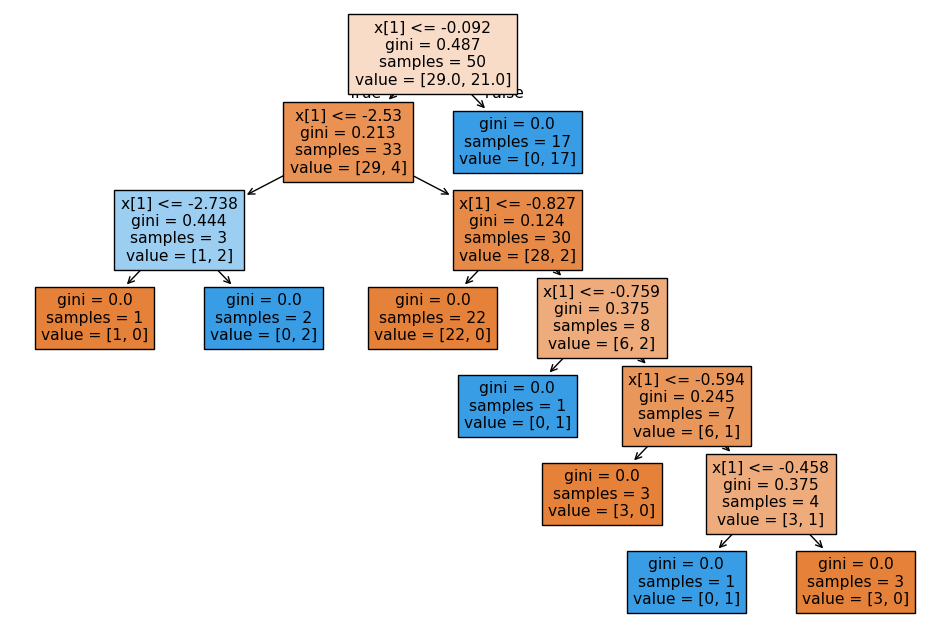

In [122]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(clf1, filled=True)

plt.show()

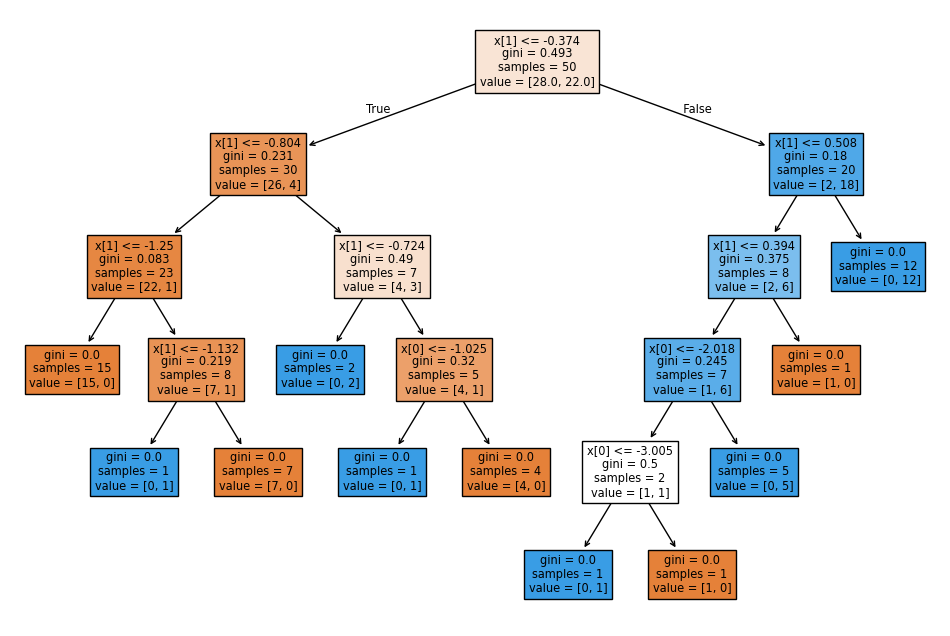

In [123]:
plt.figure(figsize=(12, 8))
plot_tree(clf2, filled=True)

plt.show()

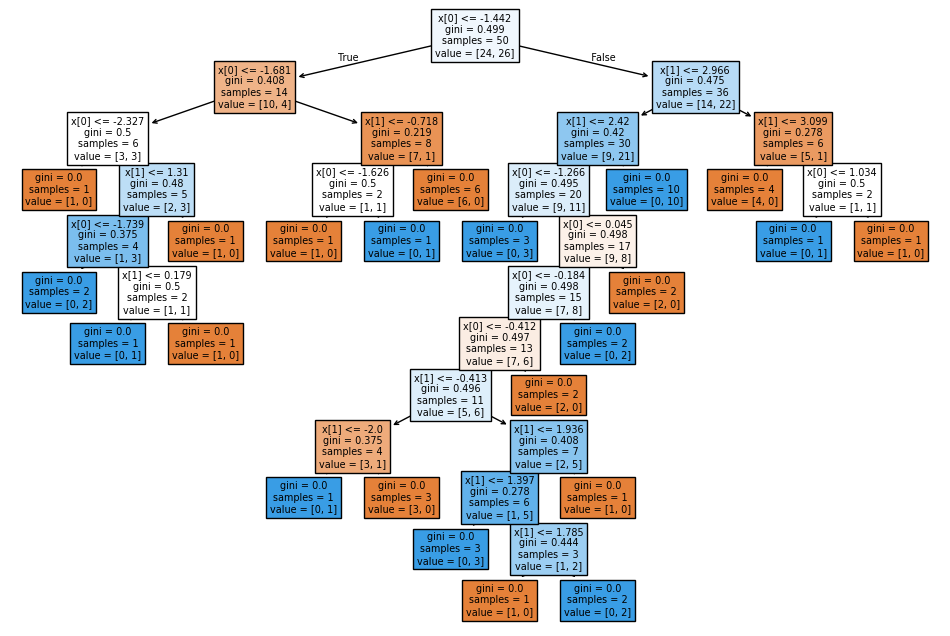

In [124]:
plt.figure(figsize=(12, 8))
plot_tree(clf3, filled=True)

plt.show()

In [125]:
import pandas as pd

sample1 = pd.DataFrame(
    [[-0.208272	 , 0.357578	]],
    columns=df1.columns[:-1]
)

clf1.predict(sample1)

array([1])

In [126]:
sample2 = pd.DataFrame(
    [[-0.208272 , 	0.357578	]],
    columns=df2.columns[:-1]
)

clf2.predict(sample2)

array([1])

In [127]:
import pandas as pd

# Create input using the exact feature names used by df3
sample3 = pd.DataFrame(
    [[-0.208272 , 	0.357578	]],
    columns=df3.columns[:-1]
)

# Predict
pred3 = clf3.predict(sample3)

print("Prediction from clf3:", pred3)

Prediction from clf3: [0]
